In [3]:
import warnings
import os
import glob
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (normalized_mutual_info_score, 
                             adjusted_rand_score, 
                             accuracy_score,
                             homogeneity_score,
                             completeness_score,
                             silhouette_score)
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA
import tracemalloc
import time

# Import custom functions
from hungarian_algorithm import apply_hungarian_algorithm
from projection_utils import project_components
from eigen_utils import compute_sorted_eigen
from clustering_utils import perform_gmm_clustering
from adjacency_matrix_knn import compute_knn_matrices
from spca_utils import compute_spca

# Suppress warnings
warnings.filterwarnings("ignore")

In [4]:
# Define the folder path where all the .h5ad files are stored
folder_path = "/home/ines/Desktop/jsPCA/data"

# Get a list of all .h5ad files in the folder
file_paths = glob.glob(os.path.join(folder_path, "*.h5ad"))

# Example: Read the specific .h5ad file (for example, "151673.h5ad")
file_to_read = "151673.h5ad"
adata = ad.read_h5ad(os.path.join(folder_path, file_to_read))
new_adata = ad.read_h5ad(os.path.join(folder_path, file_to_read))

# Display the data
print(adata)

# Normalization
sc.pp.filter_genes(adata,min_cells=20)
sc.experimental.pp.normalize_pearson_residuals(adata)
sc.pp.scale(adata)

# Get the count of unique labels in 'ground_truth', ignoring NaN values
num_labels = adata.obs['ground_truth'].nunique()
print(f"Number of unique labels in 'ground_truth' (excluding NaN) for {file_to_read}: {num_labels}")

#X_dense = adata.X.toarray()
X_dense = adata.X
num_eigenvalues = 10

# Start memory and time tracking
tracemalloc.start()  
start_time = time.time()

# Compute knn to obtain distances and connectivity
dist_matrix, connectivity_matrix = compute_knn_matrices(adata)

# Convert the connectivity matrix to a sparse CSR matrix
connectivity_matrix = csr_matrix(connectivity_matrix)

# Add the computed distances and connectivities to the AnnData object
adata.obsp['distances'] = dist_matrix
adata.obsp['connectivities'] = connectivity_matrix

# Perform Sparse PCA (SPCA) on the standardized connectivity matrix
A = compute_spca(adata)

# Compute and sort eigenvalues and eigenvectors
sorted_eigenvalues, sorted_eigenvectors = compute_sorted_eigen(A, num_eigenvalues)


projection_df = project_components(X_dense, np.real(sorted_eigenvectors), num_eigenvalues)

gmm_clusters = perform_gmm_clustering(projection_df, num_labels, random_state=42)

# Stop memory tracking and compute elapsed time
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Record elapsed time and memory usage
during_time = time.time() - start_time
memory = peak / 1024 / 1024  # Convert to MB


# Add GMM cluster labels to the AnnData object
adata.obs['GMM_clusters'] = gmm_clusters
adata.obs['GMM_clusters_Categorical'] = pd.Categorical(gmm_clusters)

# Create a new AnnData object for storing the results
new_data = adata.copy()

# Store the memory and time information in the `uns` attribute
new_data.uns['time'] = during_time
new_data.uns['memory'] = memory

# Save the result to a new file
result_path = '/home/ines/Desktop/jsPCA/data'

#new_data.write(f'{result_path}/sPCA_151673.h5ad')
print(f"Elapsed time: {during_time:.2f} seconds")
print(f"{memory:.2f} MB")

AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'Region', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
Number of unique labels in 'ground_truth' (excluding NaN) for 151673.h5ad: 7
Automatically selected k = 18
KNN graph construction successful!
Elapsed time: 20.37 seconds
738.59 MB


# Visualization 

In [5]:
# Apply Hungarian algorithm for label matching and update AnnData object
gt_key = 'Region'  # Ground truth labels column name

# Drop NaNs before applying the Hungarian algorithm
cluster_labels = adata.obs['GMM_clusters_Categorical']
valid_idx = ~adata.obs[gt_key].isna() & ~cluster_labels.isna()
valid_gt_result = adata.obs[gt_key][valid_idx]
valid_cluster_labels = cluster_labels[valid_idx]

# Apply the Hungarian algorithm for label matching
mapped_labels = apply_hungarian_algorithm(valid_gt_result, valid_cluster_labels)

# Create a full-length array with NaNs in the original NaN positions
full_mapped_labels = np.full(len(adata), np.nan, dtype=object)
full_mapped_labels[valid_idx] = mapped_labels

# Update the AnnData object with the matched cluster labels
adata.obs['GMM_clusters_Hungarian'] = pd.Categorical(full_mapped_labels, categories=adata.obs[gt_key].cat.categories)


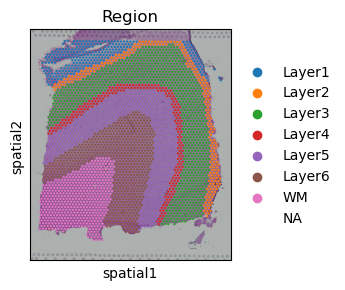

In [6]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.spatial(adata, img_key="hires", color=["Region"], spot_size=100)

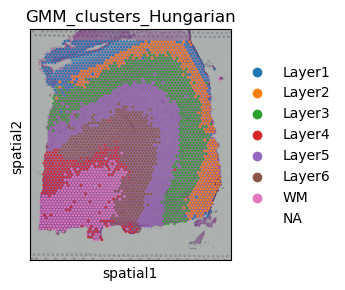

In [7]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.spatial(adata, img_key="hires", color=["GMM_clusters_Hungarian"], spot_size=100)

In [8]:
# Compute ARI (Adjusted Rand Index)
obs_df = adata.obs.dropna()
ari = adjusted_rand_score(obs_df['GMM_clusters_Hungarian'], obs_df['ground_truth'])
nmi = normalized_mutual_info_score(obs_df['GMM_clusters_Hungarian'], obs_df['ground_truth'])
print(f'ARI: {ari}')
print(f'NMI: {nmi}')

ARI: 0.5712183301759346
NMI: 0.6724428247342276


In [9]:
# Save ARI and NMI to an Excel file
ari_nmi_df = pd.DataFrame({'ARI': [ari], 'NMI': [nmi]})
ari_nmi_df.to_excel('/home/ines/Desktop/jsPCA/data/sPCA_151673_metrics.xlsx', index=False)

# Save time and memory usage to another Excel file
performance_df = pd.DataFrame({'Time (seconds)': [during_time], 'Memory (MB)': [memory]})
performance_df.to_excel('/home/ines/Desktop/jsPCA/data/sPCA_151673_scalability.xlsx', index=False)

print("Results successfully saved to Excel files.")


Results successfully saved to Excel files.
